In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Downloads/Housing_Price_Data.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [16]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [20]:
df.duplicated().sum()

0

# Preprocesing

In [27]:
# Select boolean columns
boolean_cols = df.select_dtypes(include='object').columns

# Convert 'yes' and 'no' to 1 and 0 of boolean_cols.
for col in boolean_cols:
    df[col] = df[col].replace({'yes':1, 'no':0})

C:\Users\Shiva\AppData\Local\Temp\ipykernel_15920\4056733598.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes':1, 'no':0})


In [29]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Preprocessing in Furnishing_status.
cat = ['furnishingstatus']
dummy = pd.get_dummies(df[cat]).astype(int)

df = pd.concat([df, dummy], axis=1)
df = df.drop(cat, axis=1)

In [35]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


# Data Visualization

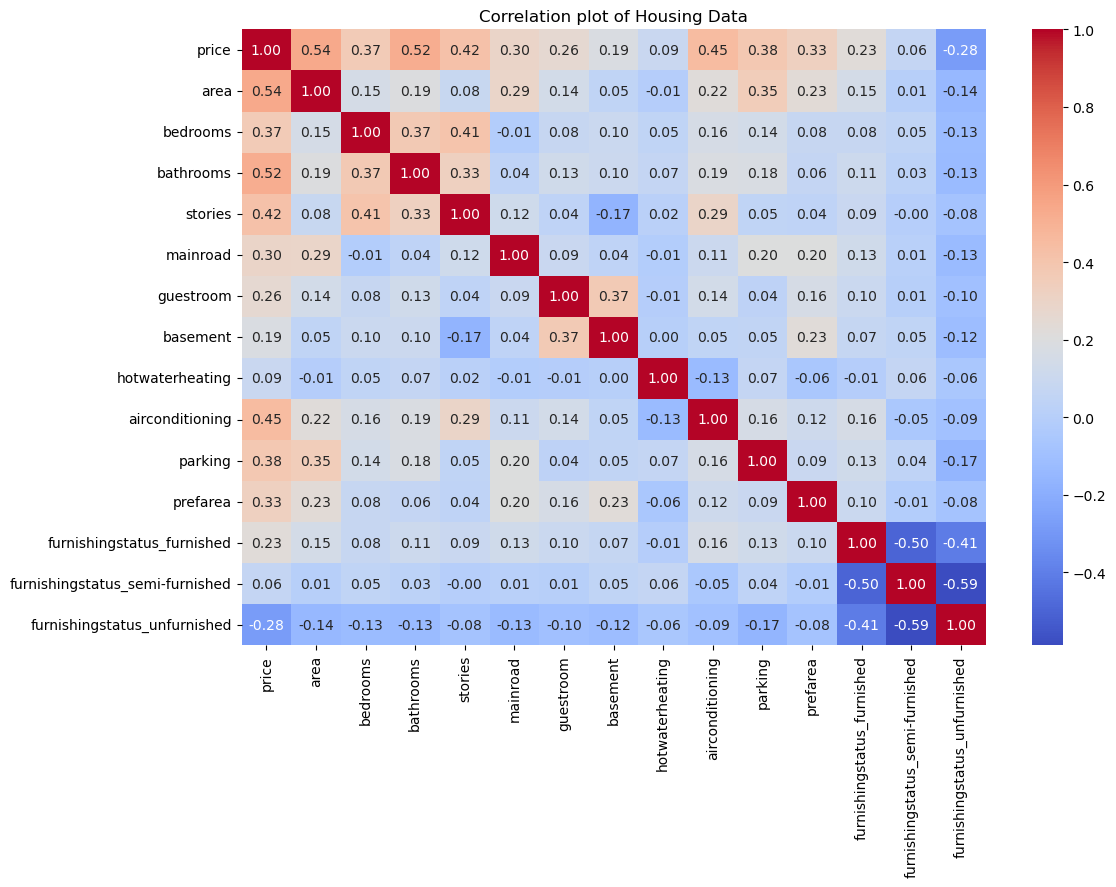

In [70]:
# Calculate the correlation matrix
correlation_matrix = df.corr()
# Create a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation plot of Housing Data')
plt.show()

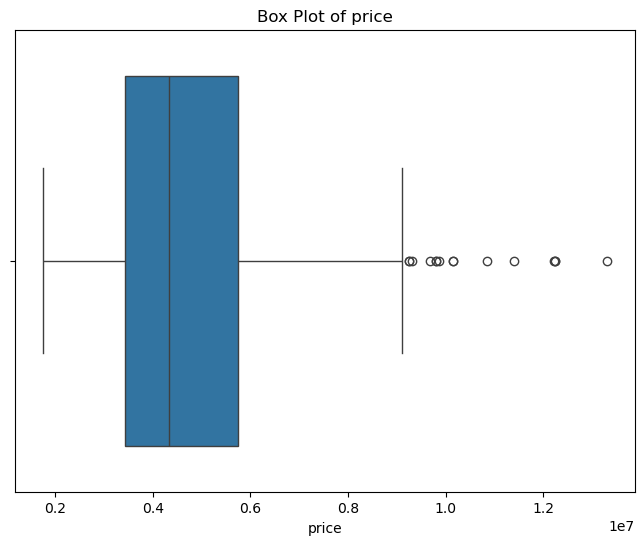

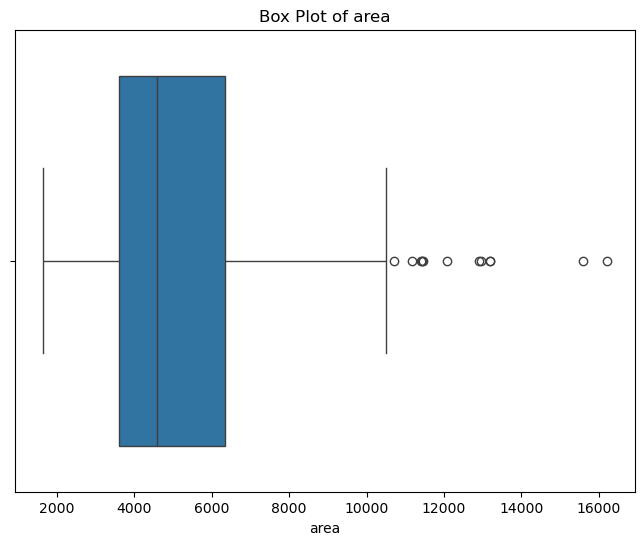

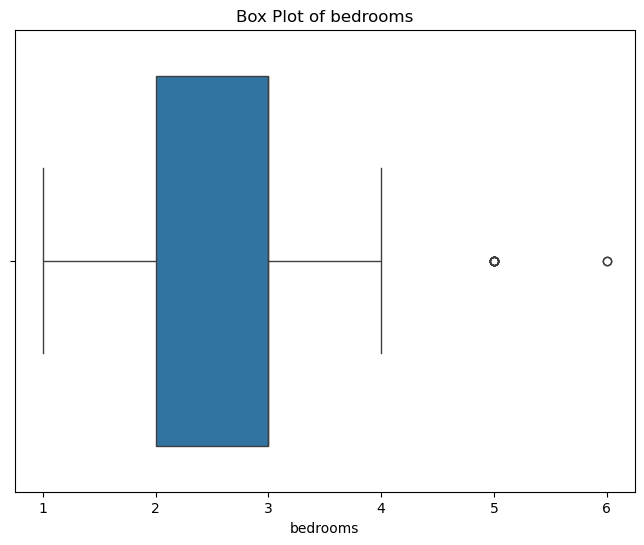

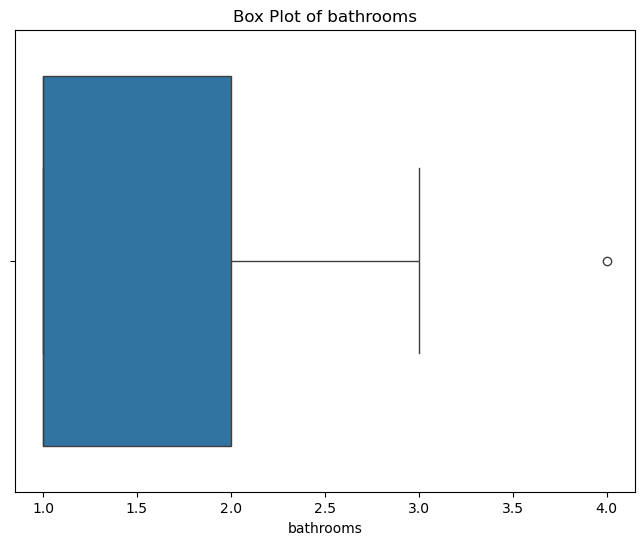

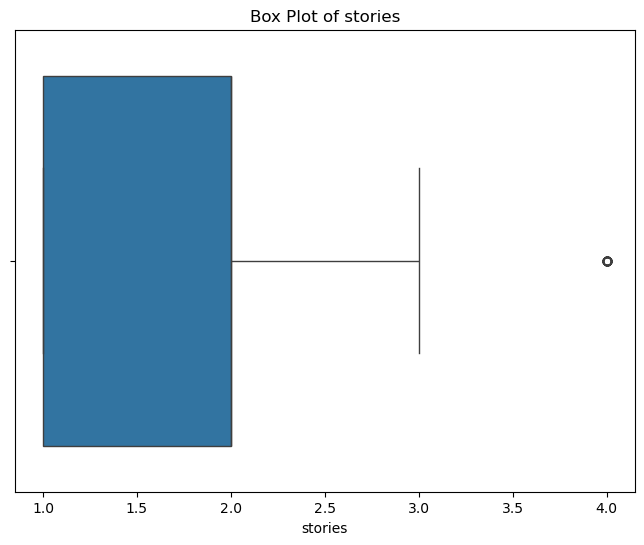

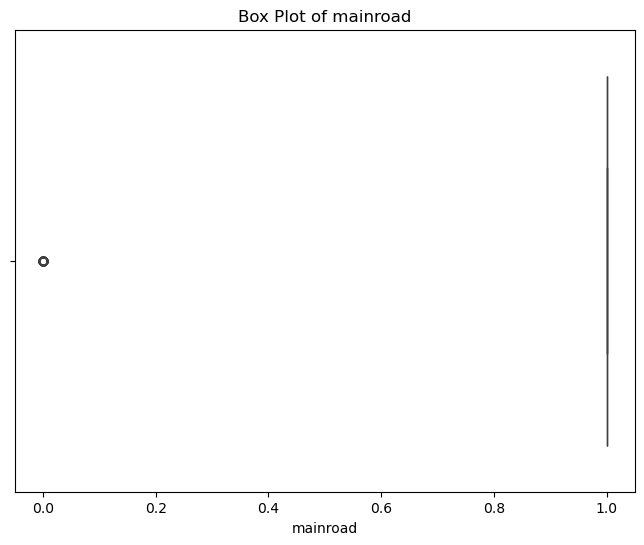

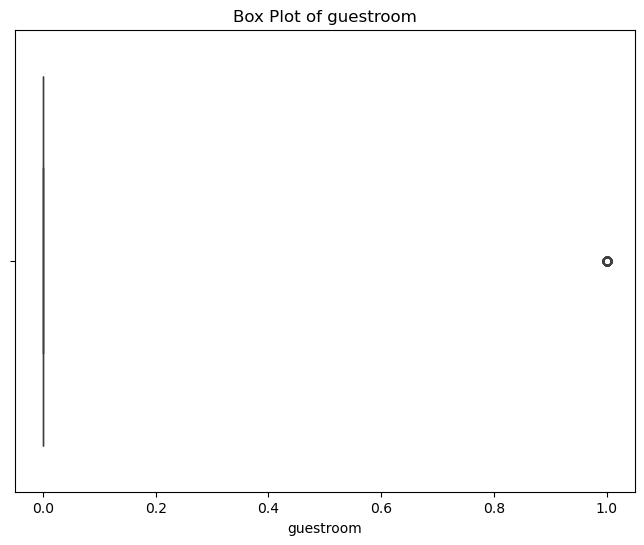

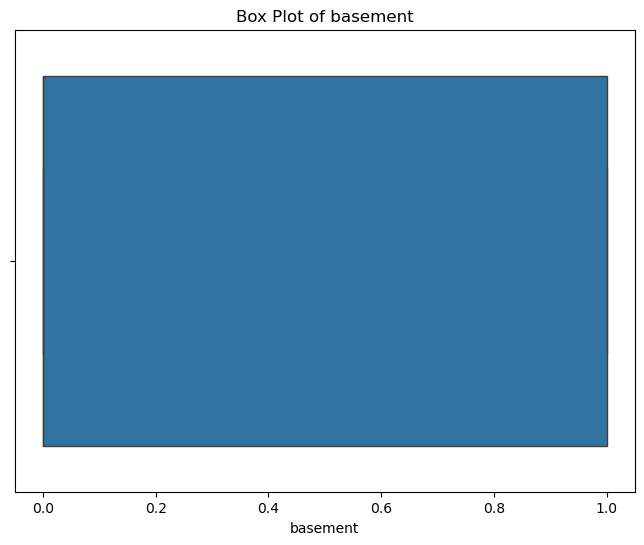

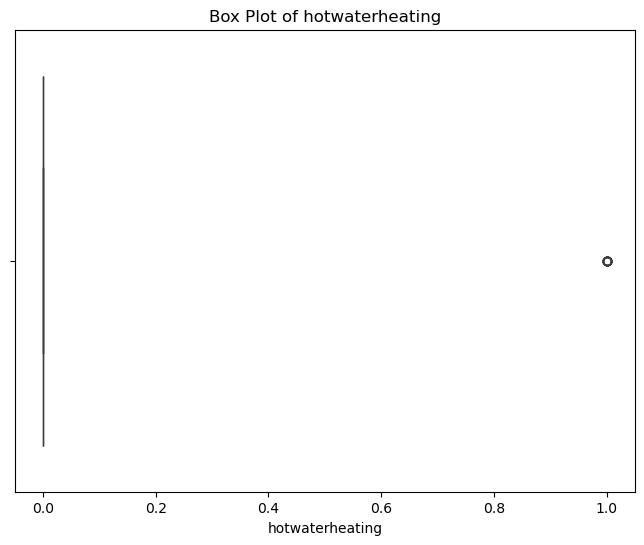

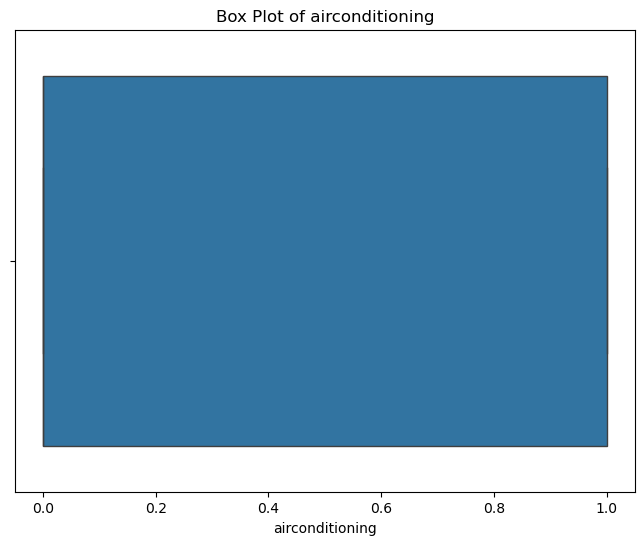

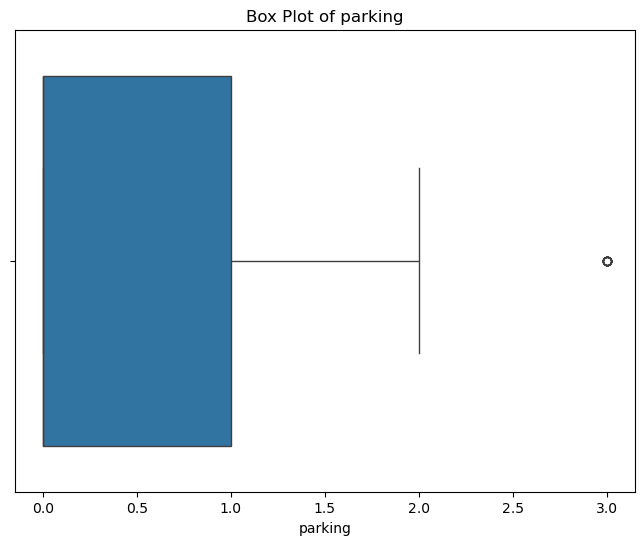

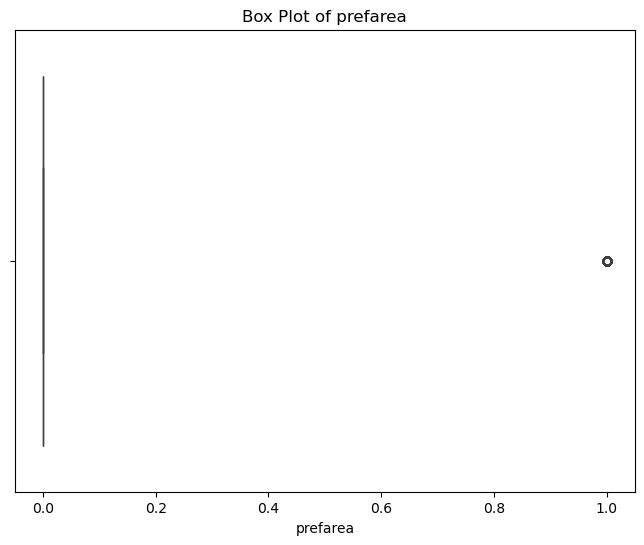

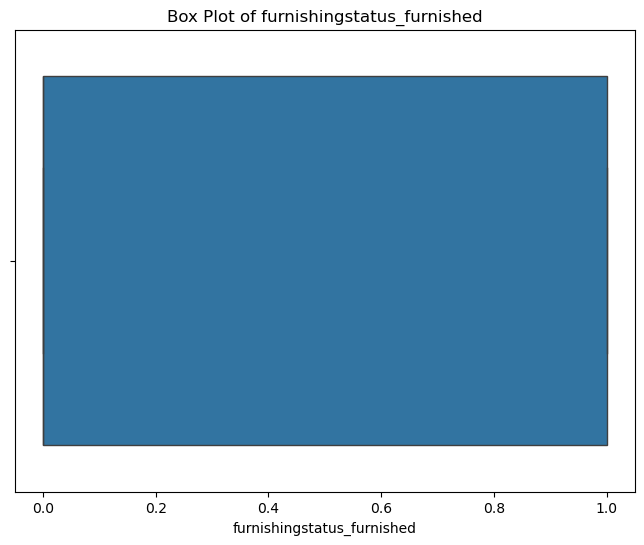

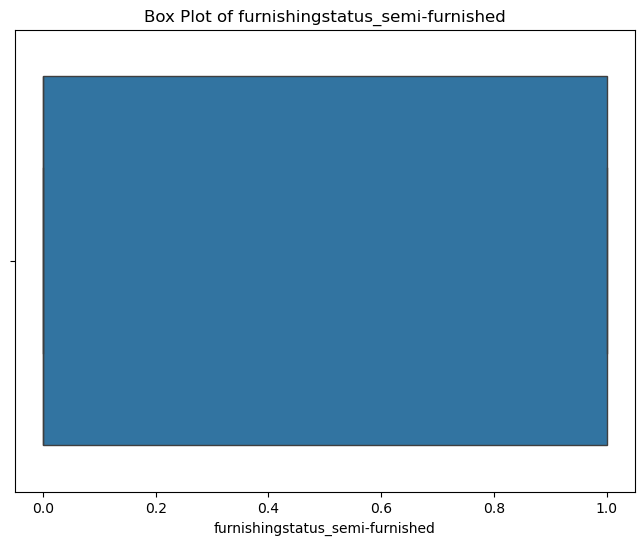

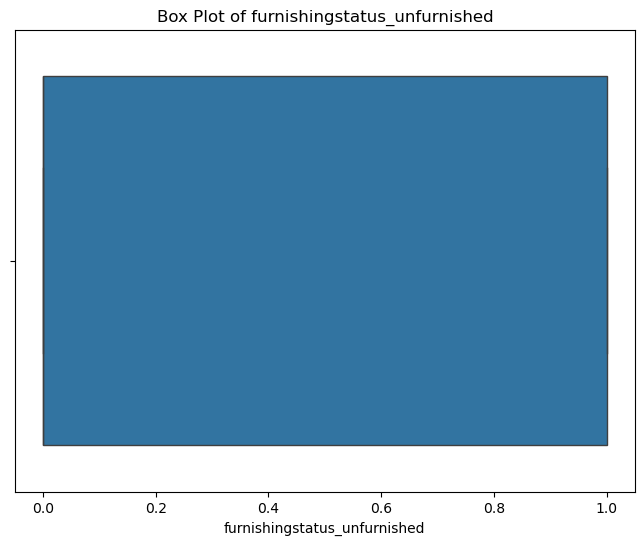

In [72]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Create Box plot for numerical columns to visulaize outliers.
for col in numerical_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

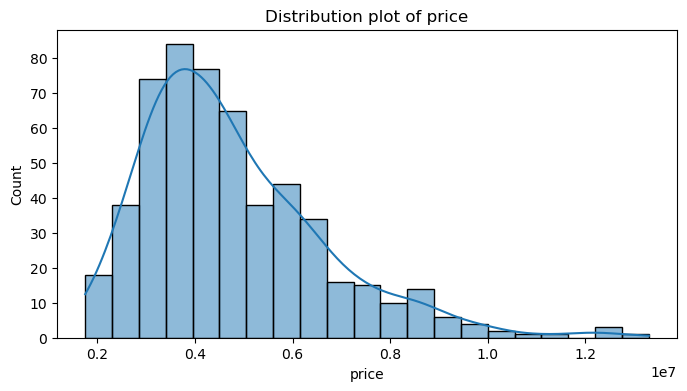

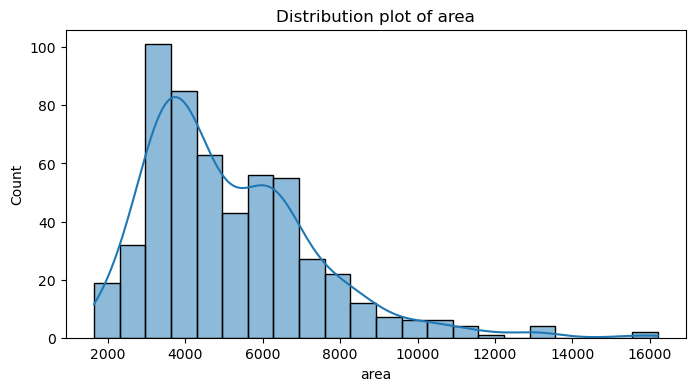

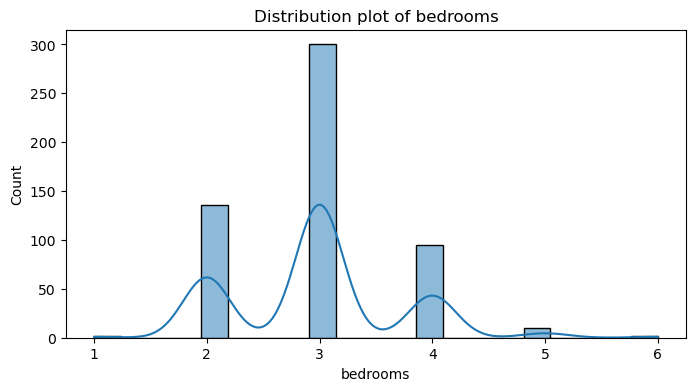

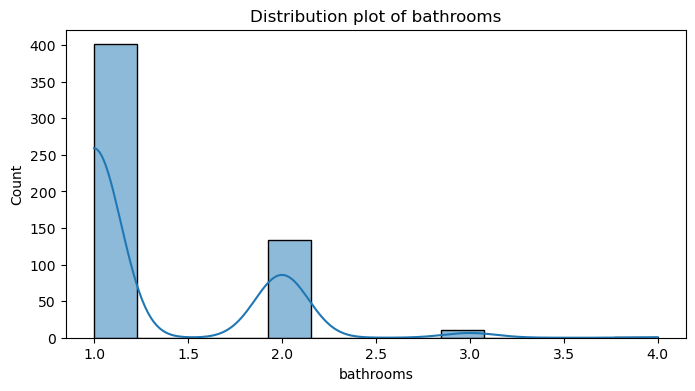

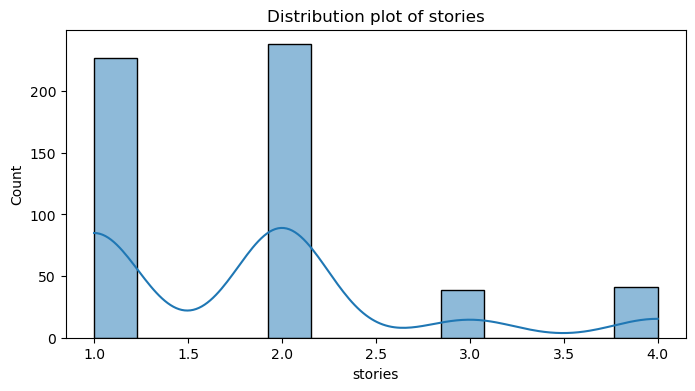

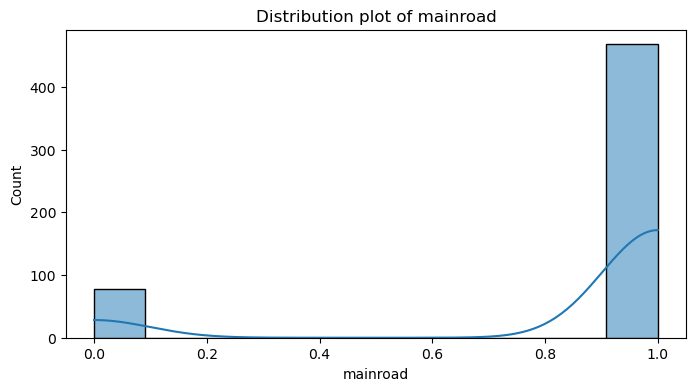

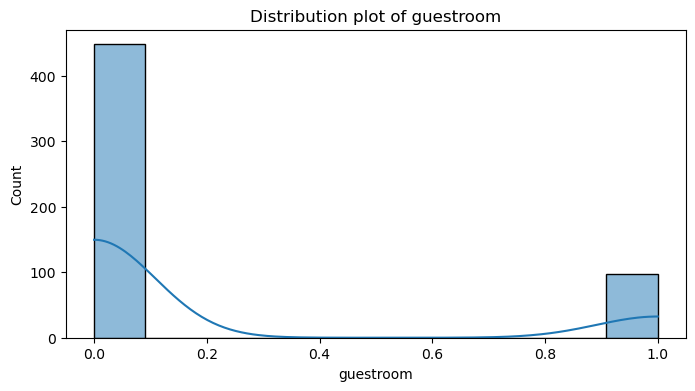

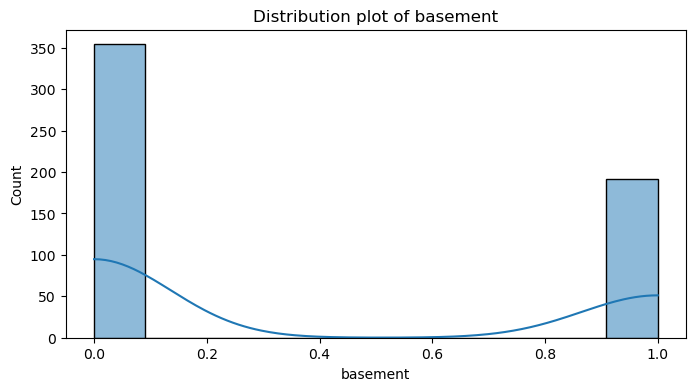

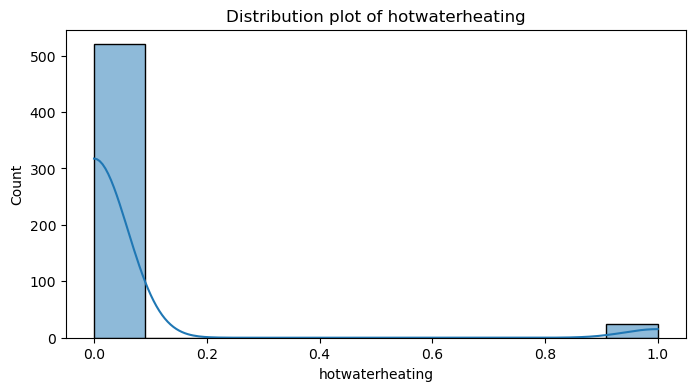

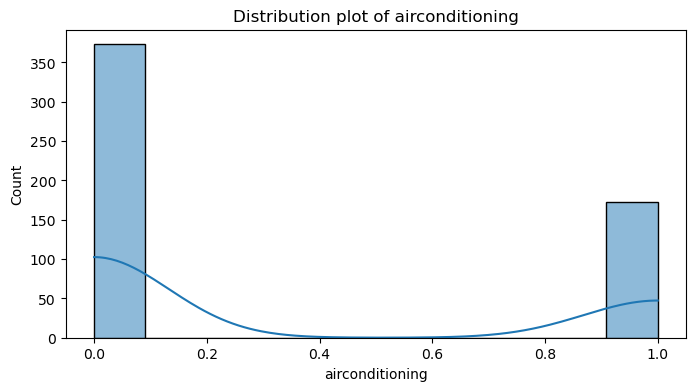

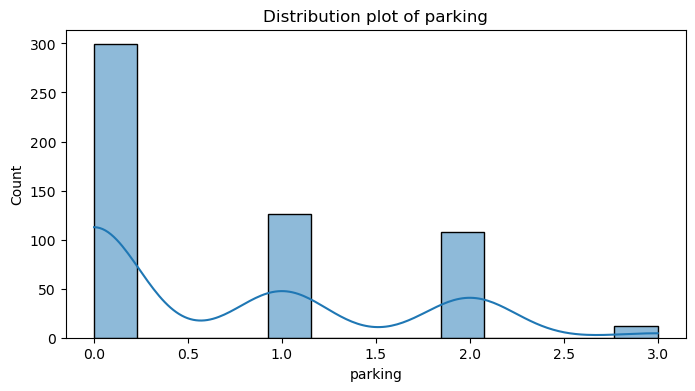

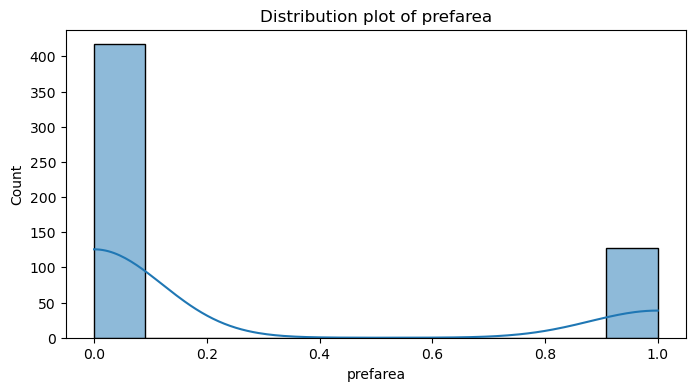

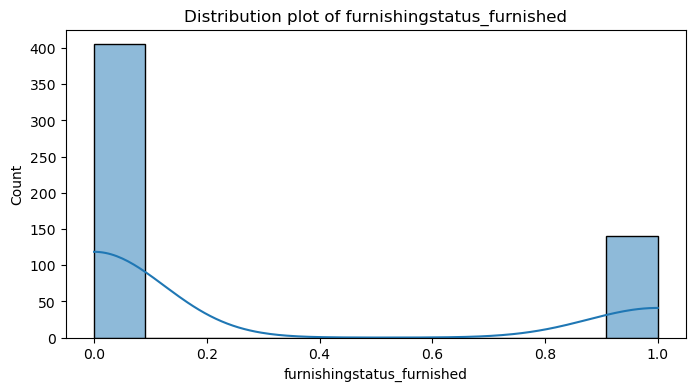

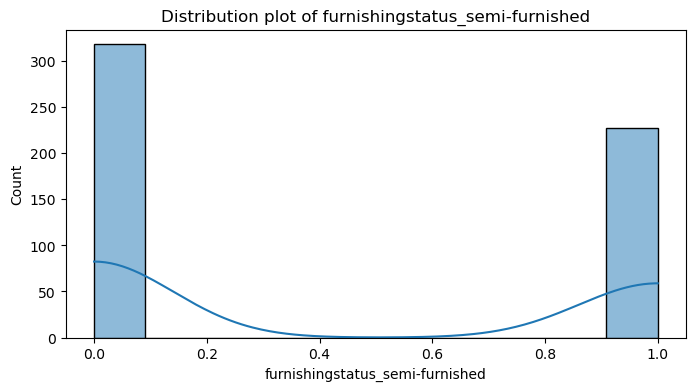

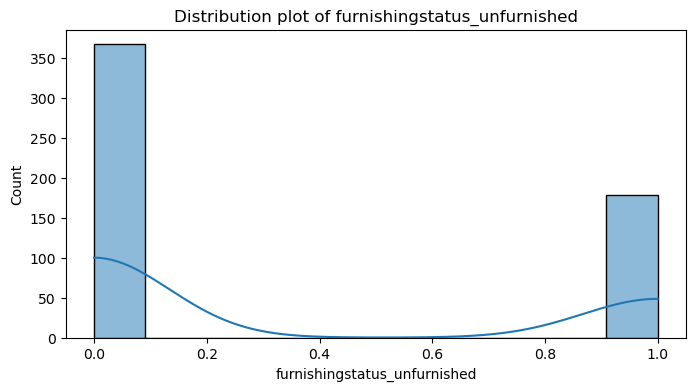

In [78]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
# Create distribution plot of numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution plot of {col}')
    plt.show()

# Outliers Detection

In [83]:
num_cols = df.drop('price', axis=1).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Define Outlier Threesold
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

#Check how many outliers columns have.
outlier_counts = ((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum()
print(outlier_counts)

area                                12
bedrooms                            12
bathrooms                            1
stories                             41
mainroad                            77
guestroom                           97
basement                             0
hotwaterheating                     25
airconditioning                      0
parking                             12
prefarea                           128
furnishingstatus_furnished           0
furnishingstatus_semi-furnished      0
furnishingstatus_unfurnished         0
dtype: int64


In [93]:
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

for col in num_cols:
    df[col] = np.where(df[col] < lower_bound[col], lower_bound[col],
                       np.where(df[col] > upper_bound[col], upper_bound[col], df[col]))


((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum()

area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
dtype: int64

In [95]:
# Train_test_split
X = df.drop('price', axis=1)
y = df['price']

# Split into train(80) and test(20)
from sklearn.model_selection import train_test_split

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [101]:
# Initializing Robust Scaler
from sklearn.preprocessing import RobustScaler, StandardScaler
scaler = RobustScaler()

# Fit on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Convert back to datafram for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Quick Check
print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (436, 14)
Test shape: (109, 14)


In [113]:
# Sk_learn models + MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    "MLPRegressor": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "R² Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

In [119]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

tf.random.set_seed(42)

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')   # regression output
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    verbose=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True
        )
    ]
)

# Predict with NN
y_pred_nn = nn_model.predict(X_test_scaled).reshape(-1)

results.append({
    "Model": "Keras_NN",
    "R² Score": r2_score(y_test, y_pred_nn),
    "MAE": mean_absolute_error(y_test, y_pred_nn),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_nn))
})

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [121]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R² Score", ascending=False)
results_df

,Model,R² Score,MAE,RMSE
5,MLPRegressor,0.643600,9.762174e+05,1.342181e+06
2,Lasso,0.640455,9.771690e+05,1.348090e+06
0,LinearRegression,0.640065,9.696834e+05,1.348820e+06
1,Ridge,0.639937,9.774893e+05,1.349061e+06
6,Keras_NN,0.627482,1.017895e+06,1.372194e+06
4,GradientBoosting,0.559884,1.055515e+06,1.491509e+06
3,RandomForest,0.548493,1.076907e+06,1.510687e+06


In [125]:
print("Final Model Comparison Summary")
display(results_df)

print("""
The dataset was cleaned and preprocessed by:
• Converting categorical variables to numeric (0/1)
• Handling outliers using IQR capping
• Applying RobustScaler to mitigate the effect of remaining outliers
• Splitting data into training and testing sets

Model Performance Summary:
• Gradient Boosting achieved the highest R² score (~0.64) with the lowest RMSE and MAE.
• Neural models (MLPRegressor and Keras Neural Network) performed competitively,
  confirming that the target variable has some non-linear relationships with predictors.
• Linear, Ridge, and Lasso regressions produced similar results (~0.64 R²),
  showing that a linear component is also present in the data.
• Random Forest performed slightly worse, likely due to parameter defaults or limited data size.

Conclusion:
Gradient Boosting currently provides the best performance among tested models.
However, further improvements can be made by:
• Performing hyperparameter tuning for Gradient Boosting, XGBoost, and LightGBM
• Experimenting with deeper or regularized neural networks
• Using cross-validation to obtain more robust performance estimates
""")

Final Model Comparison Summary


,Model,R² Score,MAE,RMSE
5,MLPRegressor,0.643600,9.762174e+05,1.342181e+06
2,Lasso,0.640455,9.771690e+05,1.348090e+06
0,LinearRegression,0.640065,9.696834e+05,1.348820e+06
1,Ridge,0.639937,9.774893e+05,1.349061e+06
6,Keras_NN,0.627482,1.017895e+06,1.372194e+06
4,GradientBoosting,0.559884,1.055515e+06,1.491509e+06
3,RandomForest,0.548493,1.076907e+06,1.510687e+06



The dataset was cleaned and preprocessed by:
• Converting categorical variables to numeric (0/1)
• Handling outliers using IQR capping
• Applying RobustScaler to mitigate the effect of remaining outliers
• Splitting data into training and testing sets

Model Performance Summary:
• Gradient Boosting achieved the highest R² score (~0.64) with the lowest RMSE and MAE.
• Neural models (MLPRegressor and Keras Neural Network) performed competitively,
  confirming that the target variable has some non-linear relationships with predictors.
• Linear, Ridge, and Lasso regressions produced similar results (~0.64 R²),
  showing that a linear component is also present in the data.
• Random Forest performed slightly worse, likely due to parameter defaults or limited data size.

Conclusion:
Gradient Boosting currently provides the best performance among tested models.
However, further improvements can be made by:
• Performing hyperparameter tuning for Gradient Boosting, XGBoost, and LightGBM
• Exper